# 🚀 Tutorial: From Data to Model Pipeline with Machine Learning
## Super AI Engineer Season 6 LV1: Zero to Hero

**ผู้สอน:** Norapat Buppodom - AI Engineer, Metier (Thailand)

---

Notebook นี้เป็น hands-on tutorial ที่จะพาทุกคนผ่าน **ML Pipeline** ตั้งแต่ข้อมูลดิบไปจนถึงโมเดลที่พร้อมใช้งาน

### 📚 สิ่งที่จะได้เรียนรู้
1. ทำความเข้าใจ Dataset (ID, Features, Label)
2. Data Preprocessing (Missing Values, Outliers, Encoding, Scaling)
3. Feature Selection & Engineering
4. การเทรนโมเดล & แก้ปัญหา Overfitting
5. Classification Metrics (Precision, Recall, F1)
6. Regression Metrics (MAE, MSE, RMSE, R²)
7. Ensemble Methods
8. AutoML ด้วย PyCaret
9. Text → Numerical ด้วย Sentence Transformers

## ⚙️ ติดตั้ง Libraries

In [ ]:
# ติดตั้ง libraries ที่จำเป็น
!pip install -q autogluon sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.1/452.1 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.8/244.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 3.9 MB/s eta 0:00

In [ ]:
!gdown --id 1-tIdvCrF736FoWS0mteW_a4koge0GWBl
!unzip /content/titanic.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-tIdvCrF736FoWS0mteW_a4koge0GWBl
To: /content/titanic.zip
100% 34.9k/34.9k [00:00<00:00, 59.5MB/s]
Archive:  /content/titanic.zip
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
# Import libraries หลัก
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    mean_absolute_error, mean_squared_error, r2_score, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

# ตั้งค่า style สำหรับกราฟ
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ Import สำเร็จ!")

✅ Import สำเร็จ!


---
# 📋 Section 2: ทำความเข้าใจ Dataset

## แนวคิดหลักของ Machine Learning

> **"โมเดล Machine Learning ที่เราจะทำก็คือ Function"**
>
> `Features (Input) → [Function/Model] → Label (Output)`

### คอลัมน์ใน Dataset มี 3 ประเภท:
| สี | ประเภท | ตัวอย่าง | หน้าที่ |
|---|---|---|---|
| 🔵 **น้ำเงิน** | ID | PassengerId | อ้างอิงเท่านั้น **ห้ามเทรน!** |
| 🟡 **เหลือง** | Features | Age, Sex, Fare | Input ของโมเดล |
| 🟢 **เขียว** | Label | Survived | Output ที่ต้องการทำนาย |

> ⚠️ **"Garbage in, Garbage out"** — ข้อมูลแย่ = ผลลัพธ์แย่

In [ ]:
# โหลด Titanic dataset

df = pd.read_csv('train.csv')
print(f"📊 Dataset shape: {df.shape}")
print(f"   - จำนวนตัวอย่าง (rows): {df.shape[0]}")
print(f"   - จำนวน features (columns): {df.shape[1]}")
df.head(10)

📊 Dataset shape: (891, 12)
   - จำนวนตัวอย่าง (rows): 891
   - จำนวน features (columns): 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
# โหลด Titanic dataset Test

df_test = pd.read_csv('test.csv')
print(f"📊 Dataset shape: {df_test.shape}")
print(f"   - จำนวนตัวอย่าง (rows): {df_test.shape[0]}")
print(f"   - จำนวน features (columns): {df_test.shape[1]}")
df_test.head(10)

📊 Dataset shape: (418, 11)
   - จำนวนตัวอย่าง (rows): 418
   - จำนวน features (columns): 11


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [ ]:
# ดูข้อมูลเบื้องต้น
print("📋 ข้อมูลทั่วไป:")
print("=" * 50)
df.info()
print("\n📊 สถิติเชิงตัวเลข:")
df.describe()

📋 ข้อมูลทั่วไป:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

📊 สถิติเชิงตัวเลข:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 🔀 Train vs Test Split

> **"AI จะเก่งได้ ต้องมีตัวอย่างให้เค้าเรียนก่อน"**

- **Train Set**: มีทั้ง Features และ Label → ใช้สอนโมเดล
- **Test Set**: มีแค่ Features → ใช้ทดสอบจริง

### กฎเหล็ก:
1. ❌ **ID ห้ามเอาไปเทรน** — "เราจะใช้ ID ในการอ้างอิง Example เท่านั้น"
2. ❌ **ข้อมูล Test ห้ามซ้ำกับ Train** — ป้องกัน Data Leakage
3. ⚠️ **Data Leakage** = "จำข้อสอบไปตอบ" — โมเดลเห็น test data ตอนเทรน

### ประเภทของ ML:
| ประเภท | Output | ตัวอย่าง |
|---|---|---|
| **Classification** | Category | ฝนตกมั้ย? (ตก/ไม่ตก) |
| **Regression** | Number | ฝนตกกี่ มม.? |

In [ ]:
# แยก Train / Test (80/20) — เราจะใช้ train ในการเรียนรู้ตลอด tutorial นี้
# ในชีวิตจริง test set จะไม่มี label แต่เราแยกไว้เพื่อจำลองสถานการณ์

X = df.drop(columns=['Survived'])  # Features
y = df['Survived']  # Label

X_train_full, X_validation, y_train_full, y_validation = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📦 Train set: {X_train_full.shape[0]} ตัวอย่าง")
print(f"🧪 Test set:  {X_validation.shape[0]} ตัวอย่าง")
print(f"\n📊 สัดส่วน Label (Train):")
print(y_train_full.value_counts(normalize=True).to_string())

📦 Train set: 712 ตัวอย่าง
🧪 Test set:  179 ตัวอย่าง

📊 สัดส่วน Label (Train):
Survived
0    0.616573
1    0.383427


---
# 🧹 Section 3: Data Preprocessing

> **"ต้อง Clean ก่อน"** — ข้อมูลดิบมักมีปัญหาที่ต้องจัดการก่อนเทรนโมเดล
>
> ⚠️ **สำคัญ: ทั้ง Train และ Test ต้อง process ด้วยวิธีเดียวกัน**

### Checklist ก่อนเทรนโมเดล:
- [✅] Handling Missing Values
- [✅] Remove Outliers
- [✅] Feature Scaling
- [✅] One-hot Encoding
- [✅] Selecting Important Information

In [ ]:
# ใช้ train set เป็นหลักในการทำความเข้าใจและ preprocess
df_work = X_train_full.copy()
df_work['Survived'] = y_train_full.values

print("🔍 Missing Values:")
print("=" * 40)
missing = df_work.isnull().sum()
missing_pct = (missing / len(df_work) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False))

🔍 Missing Values:
          Missing  Percent
Cabin         552     77.5
Age           137     19.2
Embarked        2      0.3


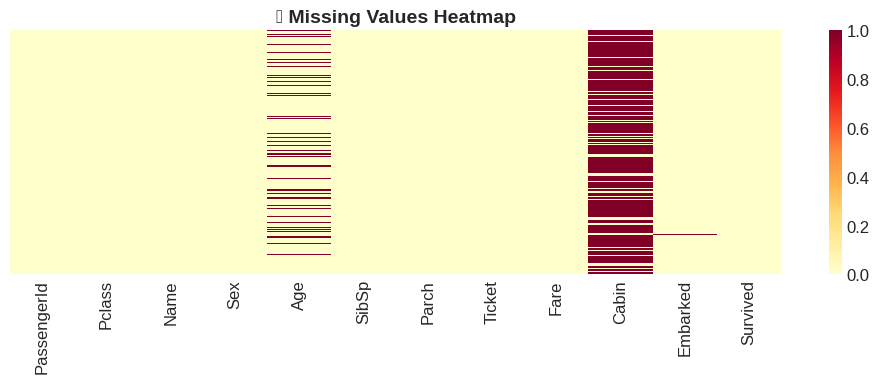

In [ ]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_work.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=ax)
ax.set_title('🔍 Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 🩹 จัดการ Missing Values
- **Age**: เติมด้วย median (ค่ากลาง) — ทนต่อ outlier ดีกว่า mean
- **Embarked / embark_town**: เติมด้วย mode (ค่าที่พบบ่อยที่สุด)
- **Deck**: missing เยอะเกินไป → drop ออก

In [ ]:
# จัดการ Missing Values

def handle_missing_values(df_run: pd.DataFrame) -> pd.DataFrame:
    df_run = df_run.copy()
    df_run['Age'] = df_run['Age'].fillna(df_run['Age'].median())
    df_run['Embarked'] = df_run['Embarked'].fillna(df_run['Embarked'].mode()[0])
    df_run.loc[~df_run['Cabin'].isna(), 'Cabin'] = 'Known'
    df_run.loc[df_run['Cabin'].isna(), 'Cabin'] = 'Unknown'
    return df_run

In [ ]:
# Drop columns ที่ missing เยอะหรือไม่จำเป็น

df_work = handle_missing_values(df_work)

print("✅ Missing values หลังจัดการ:")
print(df_work.isnull().sum()[df_work.isnull().sum() > 0])
if df_work.isnull().sum().sum() == 0:
    print("   ไม่มี missing values แล้ว! 🎉")

✅ Missing values หลังจัดการ:
Series([], dtype: int64)
   ไม่มี missing values แล้ว! 🎉


### 📦 จัดการ Outliers (ค่าผิดปกติ)
ใช้ **IQR Method** (Interquartile Range) เพื่อตรวจจับและจัดการ outliers

In [ ]:
def handle_outliers(df_run: pd.DataFrame) -> pd.DataFrame:
    df_run = df_run.copy()
    # คำนวณ IQR
    Q1 = df_run['Fare'].quantile(0.25)
    Q3 = df_run['Fare'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_outliers = ((df_run['Fare'] < lower_bound) | (df_run['Fare'] > upper_bound)).sum()
    print(f"🔍 IQR Method: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"   Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"   Found Outliers: {n_outliers} examples")

    # Clip outliers แทนการลบทิ้ง (เก็บข้อมูลไว้)
    df_run['Fare'] = df_run['Fare'].clip(lower=lower_bound, upper=upper_bound)

    return df_run

🔍 IQR Method: Q1=7.90, Q3=31.00, IQR=23.10
   Bounds: [-26.76, 65.66]
   Found Outliers: 91 examples


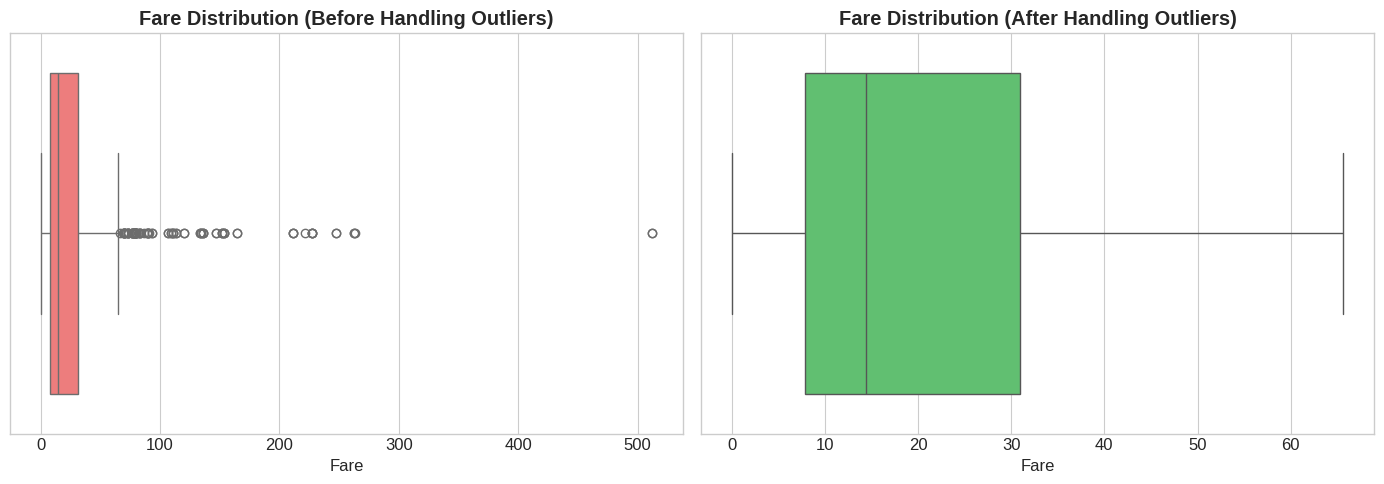

In [ ]:
# ดู distribution ของ Fare (มักมี outliers)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].set_title('Fare Distribution (Before Handling Outliers)', fontweight='bold')
sns.boxplot(data=df_work, x='Fare', ax=axes[0], color='#ff6b6b')
axes[0].set_xlabel('Fare')

df_work = handle_outliers(df_work)

# After
axes[1].set_title('Fare Distribution (After Handling Outliers)', fontweight='bold')
sns.boxplot(data=df_work, x='Fare', ax=axes[1], color='#51cf66')
axes[1].set_xlabel('Fare')

plt.tight_layout()
plt.show()

### 🔢 Encoding: แปลง Category → ตัวเลข

> **"Machine Learning เข้าใจแค่ตัวเลขเท่านั้น"**
>
> "ถ้า Feature เราไม่ใช่ตัวเลข ต้องแปลงเป็นตัวเลขก่อน"

⚠️ **Category vs Numerical — เป็นตัวเลขเหมือนกัน แต่ทำงานไม่เหมือนกัน**
- **Category**: ไม่มี Scale ชัดเจน (เช่น Sex: 0, 1)
- **Numerical**: มี Scale ชัดเจน (เช่น Age: 27, 19, 14)

In [ ]:
# Label Encoding สำหรับ binary category
def handle_encoding(df_run: pd.DataFrame, sex_encoder, is_train = True) -> pd.DataFrame:
    df_run = df_run.copy()
    if is_train:
        df_run['sex_encoded'] = sex_encoder.fit_transform(df_run['Sex'])  # male=1, female=0
    else:
        df_run['sex_encoded'] = sex_encoder.transform(df_run['Sex'])  # male=1, female=0
    print("🔢 Sex encoding:", dict(zip(sex_encoder.classes_, sex_encoder.transform(sex_encoder.classes_))))

    # One-Hot Encoding สำหรับ multi-class category
    df_run = pd.get_dummies(df_run, columns=['Embarked'], prefix='Embarked', dtype=int)
    df_run = pd.get_dummies(df_run, columns=['Pclass'], prefix='Pclass', dtype=int)
    df_run = pd.get_dummies(df_run, columns=['Cabin'], prefix='Pclass', dtype=int)

    # Drop original text columns ที่ไม่ต้องใช้แล้ว
    cols_to_drop = ['PassengerId', 'Sex', 'embark_town', 'Ticket']
    df_run = df_run.drop(columns=[c for c in cols_to_drop if c in df_run.columns])

    return df_run

In [ ]:
sex_encoder = LabelEncoder()
df_work = handle_encoding(df_work, sex_encoder)


print("\n✅ Columns หลัง encoding:")
print(df_work.dtypes.to_string())

🔢 Sex encoding: {'female': np.int64(0), 'male': np.int64(1)}

✅ Columns หลัง encoding:
Name               object
Age               float64
SibSp               int64
Parch               int64
Fare              float64
Survived            int64
sex_encoded         int64
Embarked_C          int64
Embarked_Q          int64
Embarked_S          int64
Pclass_1            int64
Pclass_2            int64
Pclass_3            int64
Pclass_Known        int64
Pclass_Unknown      int64


### ⚖️ Feature Scaling
ปรับ scale ของ features ให้อยู่ในระดับใกล้เคียงกัน เพื่อไม่ให้ feature ที่มีค่าเยอะ (เช่น Fare 0-500) กลบ feature ที่มีค่าน้อย (เช่น Age 0-80)

In [ ]:
# Label Encoding สำหรับ binary category
def handle_feature_scaling(df_run: pd.DataFrame, scaler, is_train = True) -> pd.DataFrame:
    df_run = df_run.copy()

    # แสดง scale ก่อน
    numerical_cols = ['Age', 'Fare']
    print("📊 ก่อน Scaling:")
    print(df_run[numerical_cols].describe().loc[['mean', 'std', 'min', 'max']].round(2))

    # StandardScaler: แปลงให้ mean=0, std=1
    if is_train:
        df_run[numerical_cols] = scaler.fit_transform(df_run[numerical_cols])
    else:
        df_run[numerical_cols] = scaler.transform(df_run[numerical_cols])

    return df_run, numerical_cols

In [ ]:
scaler = StandardScaler()
df_work, numerical_cols = handle_feature_scaling(df_work, scaler)


print("\n📊 หลัง Scaling (StandardScaler):")
print(df_work[numerical_cols].describe().loc[['mean', 'std', 'min', 'max']].round(2))

📊 ก่อน Scaling:
        Age   Fare
mean  29.56  23.96
std   13.03  20.51
min    0.42   0.00
max   80.00  65.66

📊 หลัง Scaling (StandardScaler):
       Age  Fare
mean  0.00  0.00
std   1.00  1.00
min  -2.24 -1.17
max   3.88  2.03


---
# 🔧 Section 4: Feature Selection & Engineering

## Feature Selection — เลือก Features ที่สำคัญ

ปัญหา: ตอนเรียนอาจมีแค่ 10 Features 🤩 แต่ในชีวิตจริงอาจมี 100+ Features 😱

### วิธีเลือก Feature ที่เหมาะสม:
| Input | Output | วิธีที่แนะนำ |
|---|---|---|
| Numerical | Numerical | Pearson's, Spearman's |
| Numerical | Categorical | ANOVA, Kendall's |
| Categorical | Categorical | Chi-Squared, Mutual Information |

### Pearson Correlation:
- **r ≈ +1**: สัมพันธ์เชิงบวกแรง
- **r ≈ -1**: สัมพันธ์เชิงลบแรง
- **r ≈ 0**: ไม่มีความสัมพันธ์
- ⚠️ "ใช้ได้ดีกับ linear relationship เท่านั้น"

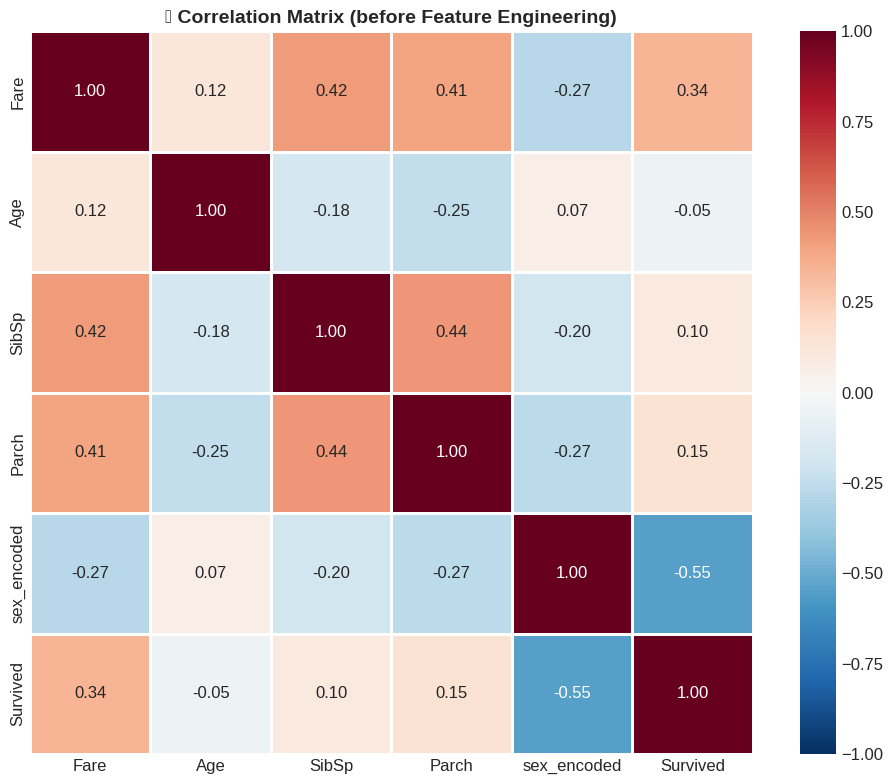


📊 Correlation with Survived (before Feature Engineering):
sex_encoded    0.549171
Fare           0.342385
Parch          0.146784
SibSp          0.097633
Age            0.050810


In [ ]:
# เตรียม DataFrame สำหรับดู correlation (ใช้ข้อมูลก่อน scaling เพื่อความเข้าใจง่าย)
df_corr = X_train_full.copy()
df_corr['Survived'] = y_train_full.values

df_corr['sex_encoded'] = sex_encoder.transform(df_corr['Sex'])  # male=1, female=0

# เลือก columns ตัวเลขที่จะดู correlation
num_cols = ['Fare', 'Age', 'SibSp', 'Parch', 'sex_encoded'] + ['Survived']

# Correlation heatmap (ก่อน Feature Engineering)
fig, ax = plt.subplots(figsize=(10, 8))
corr_before = df_corr[num_cols].corr(method='spearman')
sns.heatmap(corr_before, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title('🔍 Correlation Matrix (before Feature Engineering)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# แสดง correlation กับ survived
print("\n📊 Correlation with Survived (before Feature Engineering):")
corr_with_target = corr_before['Survived'].drop('Survived').abs().sort_values(ascending=False)
print(corr_with_target.to_string())

### Feature Engineering — สร้าง Features ใหม่ที่ดีกว่า

> **"เช่นเอา Age * Fare ^ 2 = Feature ใหม่"** — Slide แสดงแนวคิดว่า Feature ที่ noisy ทีละตัว เมื่อ engineer แล้วอาจได้ signal ที่แรงขึ้น
>
> ในทางปฏิบัติ เราจะสร้าง features ที่มี **domain knowledge** รองรับ:

#### Features ใหม่ที่จะสร้าง:
1. **`FamilySize`** = SibSp + Parch + 1 → รวมจำนวนครอบครัวทั้งหมดบนเรือ
2. **`IsAlone`** = 1 ถ้าไม่มีครอบครัว → คนเดินทางคนเดียวรอดน้อยกว่า
3. **`Title`** จากชื่อ (Mr, Mrs, Miss, Master) → สะท้อนสถานะทางสังคมและเพศ

In [ ]:
# Label Encoding สำหรับ binary category
def handle_feature_engineering(df_run: pd.DataFrame) -> pd.DataFrame:
    df_run = df_run.copy()

    df_run['FamilySize'] = df_run['SibSp'] + df_run['Parch'] + 1
    df_run['IsAlone'] = (df_run['FamilySize'] == 1).astype(int)

    # Extract Title from Name
    df_run['Title'] = df_run['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    # รวม title ที่หายากเป็น 'Rare'
    title_mapping = {
        'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    }
    df_run['Title'] = df_run['Title'].map(lambda x: title_mapping.get(x, 'Rare'))
    # Encode Title
    title_dummies = pd.get_dummies(df_run['Title'], prefix='Title', dtype=int)
    df_run = pd.concat([df_run, title_dummies], axis=1)

    return df_run

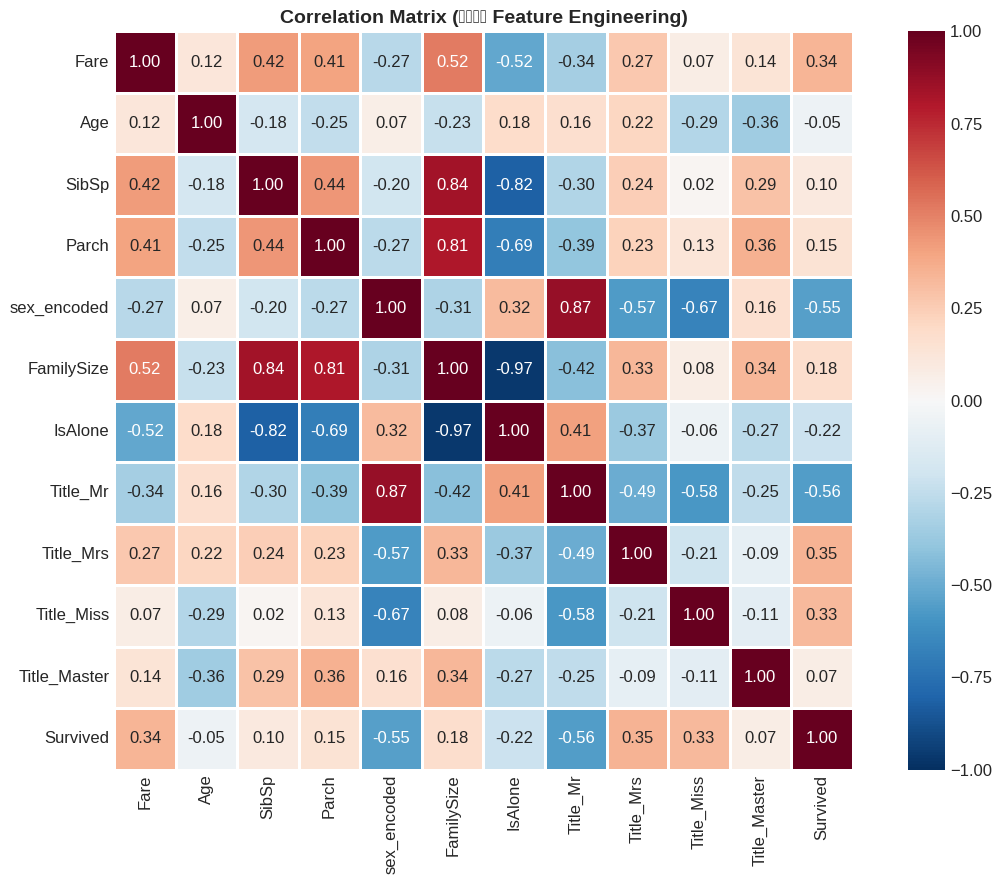

In [ ]:
df_run = handle_feature_engineering(df_corr)


df_corr['FamilySize'] = df_corr['SibSp'] + df_corr['Parch'] + 1
df_corr['IsAlone'] = (df_corr['FamilySize'] == 1).astype(int)

# Extract Title from Name
df_corr['Title'] = df_corr['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
# รวม title ที่หายากเป็น 'Rare'
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
}
df_corr['Title'] = df_corr['Title'].map(lambda x: title_mapping.get(x, 'Rare'))
# Encode Title
title_dummies = pd.get_dummies(df_corr['Title'], prefix='Title', dtype=int)
df_corr = pd.concat([df_corr, title_dummies], axis=1)

# Correlation heatmap (หลัง Feature Engineering)
new_num_cols = ['Fare', 'Age', 'SibSp', 'Parch', 'sex_encoded', 'FamilySize', 'IsAlone', 'Title_Mr', 'Title_Mrs', 'Title_Miss', 'Title_Master'] + ['Survived']


fig, ax = plt.subplots(figsize=(12, 9))
corr_after = df_corr[new_num_cols].corr(method='spearman')
sns.heatmap(corr_after, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix (หลัง Feature Engineering)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# เปรียบเทียบ Correlation กับ Survived: ก่อน vs หลัง
print("📊 เปรียบเทียบ Correlation กับ Survived")
print("=" * 55)

corr_after_target = corr_after['Survived'].drop('Survived').abs().sort_values(ascending=False)

print(f"\n{'Feature':<20} {'|r| with Survived':>18}")
print("-" * 40)
for feat in corr_after_target.index:
    val = corr_after_target[feat]
    bar = '█' * int(val * 30)
    is_new = '✨ NEW' if feat in ['FamilySize', 'IsAlone', 'Title_Mr', 'Title_Mrs', 'Title_Miss', 'Title_Master'] else ''
    print(f"{feat:<20} {val:>8.3f}  {bar} {is_new}")

print("\n💡 สังเกตว่า Title_Mr, IsAlone มี correlation ที่ดี")
print("   และ features ใหม่เหล่านี้ช่วยให้โมเดลเข้าใจข้อมูลได้ดีขึ้น!")

📊 เปรียบเทียบ Correlation กับ Survived

Feature               |r| with Survived
----------------------------------------
Title_Mr                0.556  ████████████████ ✨ NEW
sex_encoded             0.549  ████████████████ 
Title_Mrs               0.347  ██████████ ✨ NEW
Fare                    0.342  ██████████ 
Title_Miss              0.326  █████████ ✨ NEW
IsAlone                 0.216  ██████ ✨ NEW
FamilySize              0.180  █████ ✨ NEW
Parch                   0.147  ████ 
SibSp                   0.098  ██ 
Title_Master            0.072  ██ ✨ NEW
Age                     0.051  █ 

💡 สังเกตว่า Title_Mr, IsAlone มี correlation ที่ดี
   และ features ใหม่เหล่านี้ช่วยให้โมเดลเข้าใจข้อมูลได้ดีขึ้น!


### ตัดสินใจ: Features ที่จะใช้เทรนโมเดล

> **"เอา Feature ที่ไม่วิ่งตาม Label ออก"** — Drop features ที่ correlation < threshold
>
> **"Feature ที่คล้ายกันเกินไป ยุบเหลือ 1 พอ"** — Drop redundant features (r > 0.9)

---
# 🤖 Section 5: การเทรนโมเดล & Overfitting

## Overfitting = "AI จำข้อสอบไปตอบ (สิงห์สนามซ้อม)"

### แก้ปัญหาด้วย Validation Set:
- **Train** → สอนโมเดล
- **Validation** → เช็คว่าโมเดลเรียนรู้จริงหรือแค่จำ
- **Test** → ใช้จริง (ไม่มี label)

> **Overfit เมื่อ: คะแนน Train >> คะแนน Validation**

### สาเหตุ Overfitting:
1. จำนวน Features **เยอะไป** → Overfit
2. จำนวน Examples **น้อยไป** → Overfit
3. โมเดล **ใหญ่/ซับซ้อนไป** → Overfit
4. เทรนโมเดล **นานไป** → Overfit

In [ ]:
# เตรียม features สำหรับเทรนโมเดล
def prepare_features(df_raw, sex_encoder, scaler, is_train):
    """เตรียม features จาก raw dataframe"""
    df = df_raw.copy()


    df = handle_missing_values(df)
    df = handle_outliers(df)
    df = handle_encoding(df, sex_encoder, is_train = is_train)
    df, numerical_cols = handle_feature_scaling(df, scaler, is_train = is_train)

    return df.drop(columns = 'Name')

sex_encoder = LabelEncoder()
scaler = StandardScaler()
X_train_feat = prepare_features(X_train_full, sex_encoder, scaler, is_train = True)
X_validation_feat = prepare_features(X_validation, sex_encoder, scaler, is_train = False)

df_test_feature = prepare_features(df_test, sex_encoder, scaler, is_train = False)

print(f"✅ Features ที่ใช้เทรน: {list(X_train_feat.columns)}")
print(f"   จำนวน features: {X_train_feat.shape[1]}")

🔍 IQR Method: Q1=7.90, Q3=31.00, IQR=23.10
   Bounds: [-26.76, 65.66]
   Found Outliers: 91 examples
🔢 Sex encoding: {'female': np.int64(0), 'male': np.int64(1)}
📊 ก่อน Scaling:
        Age   Fare
mean  29.56  23.96
std   13.03  20.51
min    0.42   0.00
max   80.00  65.66
🔍 IQR Method: Q1=7.99, Q3=31.80, IQR=23.81
   Bounds: [-27.73, 67.51]
   Found Outliers: 24 examples
🔢 Sex encoding: {'female': np.int64(0), 'male': np.int64(1)}
📊 ก่อน Scaling:
        Age   Fare
mean  28.75  24.67
std   13.01  20.96
min    0.75   0.00
max   70.00  67.51
🔍 IQR Method: Q1=7.90, Q3=31.50, IQR=23.60
   Bounds: [-27.51, 66.91]
   Found Outliers: 55 examples
🔢 Sex encoding: {'female': np.int64(0), 'male': np.int64(1)}
📊 ก่อน Scaling:
        Age   Fare
mean  29.60  24.68
std   12.70  21.23
min    0.17   0.00
max   76.00  66.91
✅ Features ที่ใช้เทรน: ['Age', 'SibSp', 'Parch', 'Fare', 'sex_encoded', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Pclass_Known', 'Pclass_Unknown

In [ ]:
# เทรนโมเดล RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_feat, y_train_full)

# เปรียบเทียบ Train vs Validation score
train_score = rf_model.score(X_train_feat, y_train_full)
val_score = rf_model.score(X_validation_feat, y_validation)

print("🎯 ผลการเทรน RandomForestClassifier:")
print(f"   Train Accuracy:      {train_score:.4f}")
print(f"   Validation Accuracy: {val_score:.4f}")
print(f"   Gap (Train - Val):   {train_score - val_score:.4f}")

if train_score - val_score > 0.1:
    print("\n⚠️ Gap ค่อนข้างสูง → อาจมีสัญญาณ Overfitting!")
    print("   💡 ลองแก้ด้วย: ลด n_estimators, เพิ่ม min_samples_leaf, หรือลด features")
else:
    print("\n✅ Gap ไม่สูงมาก → โมเดลน่าจะ generalize ได้ดี")

🎯 ผลการเทรน RandomForestClassifier:
   Train Accuracy:      0.9860
   Validation Accuracy: 0.7709
   Gap (Train - Val):   0.2150

⚠️ Gap ค่อนข้างสูง → อาจมีสัญญาณ Overfitting!
   💡 ลองแก้ด้วย: ลด n_estimators, เพิ่ม min_samples_leaf, หรือลด features


In [ ]:
# ทดลองแก้ Overfitting ด้วยการปรับ Hyperparameters
from sklearn.model_selection import cross_val_score

configs = [
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1, "label": "Default (อาจ overfit)"},
    {"n_estimators": 50, "max_depth": 5, "min_samples_leaf": 5, "label": "Conservative"},
    {"n_estimators": 100, "max_depth": 8, "min_samples_leaf": 3, "label": "Balanced"},
]

print("🔧 เปรียบเทียบ Hyperparameters:")
print(f"{'Config':<25} {'Train':>8} {'Val':>8} {'Gap':>8}")
print("-" * 51)

for cfg in configs:
    model = RandomForestClassifier(
        n_estimators=cfg['n_estimators'],
        max_depth=cfg['max_depth'],
        min_samples_leaf=cfg['min_samples_leaf'],
        random_state=42
    )
    model.fit(X_train_feat, y_train_full)
    t_score = model.score(X_train_feat, y_train_full)
    v_score = model.score(X_validation_feat, y_validation)
    gap = t_score - v_score
    flag = "⚠️" if gap > 0.1 else "✅"
    print(f"{cfg['label']:<25} {t_score:>8.4f} {v_score:>8.4f} {gap:>8.4f} {flag}")

🔧 เปรียบเทียบ Hyperparameters:
Config                       Train      Val      Gap
---------------------------------------------------
Default (อาจ overfit)       0.9860   0.7709   0.2150 ⚠️
Conservative                0.8455   0.7877   0.0578 ✅
Balanced                    0.8933   0.7821   0.1111 ⚠️


### ⚖️ ปัญหา Imbalanced Data

> **"จำนวนของ Class ที่เราจะ Predict มีไม่เท่ากัน"**
>
> "ถ้าไม่แก้ โมเดลมีโอกาสดิ่งข้อสอบเลย เพราะดิ่ง = ได้คะแนนเกือบเต็มทันที"

**วิธีแก้:**
- **Downsampling**: ลดจำนวน majority class
- **Upsampling**: เพิ่มจำนวน minority class (เช่น SMOTE)
- **class_weight='balanced'**: ให้โมเดลให้น้ำหนัก class น้อยมากขึ้น

In [ ]:
# ดู class distribution
print("📊 สัดส่วน Class ใน Training Data:")
class_counts = y_train_full.value_counts()
for cls, count in class_counts.items():
    pct = count / len(y_train_full) * 100
    bar = '█' * int(pct / 2)
    label = "ไม่รอด" if cls == 0 else "รอด"
    print(f"   Class {cls} ({label}): {count:>4} ({pct:.1f}%) {bar}")

print("\n💡 Titanic dataset ไม่ imbalance มากนัก แต่ในชีวิตจริง")
print("   อาจเจอ 99:1 ซึ่งต้องจัดการอย่างจริงจัง")

📊 สัดส่วน Class ใน Training Data:
   Class 0 (ไม่รอด):  439 (61.7%) ██████████████████████████████
   Class 1 (รอด):  273 (38.3%) ███████████████████

💡 Titanic dataset ไม่ imbalance มากนัก แต่ในชีวิตจริง
   อาจเจอ 99:1 ซึ่งต้องจัดการอย่างจริงจัง


---
# 📏 Section 6: Classification Evaluation Metrics

> **"Precision และ Recall สร้างมาสู้รบกับ Imbalanced Dataset"**

### เปรียบเทียบ Precision vs Recall:

| Metric | ความหมาย | เมื่อไหร่ใช้ | Analogy |
|---|---|---|---|
| **Precision** | ทำนายว่า Yes แล้วถูกจริงกี่% | เน้นถูกต้อง ผิดพลาดแพง | จับปลาได้ 10 ตัว ปลาจริง 8 = 80% |
| **Recall** | ของที่เป็น Yes จริง จับได้กี่% | เน้นครบถ้วน พลาดไม่ได้ | ปลา 100 ตัว จับได้ 8 = 8% |
| **F1-Score** | Harmonic mean ของทั้งสอง | ต้องการสมดุล | - |

### Use Cases:
- **Precision สำคัญ**: ระบบเทรดอัตโนมัติ (ทำผิด = เสียหายมาก)
- **Recall สำคัญ**: ตรวจจับของเสีย (พลาด = เสียหายมาก)

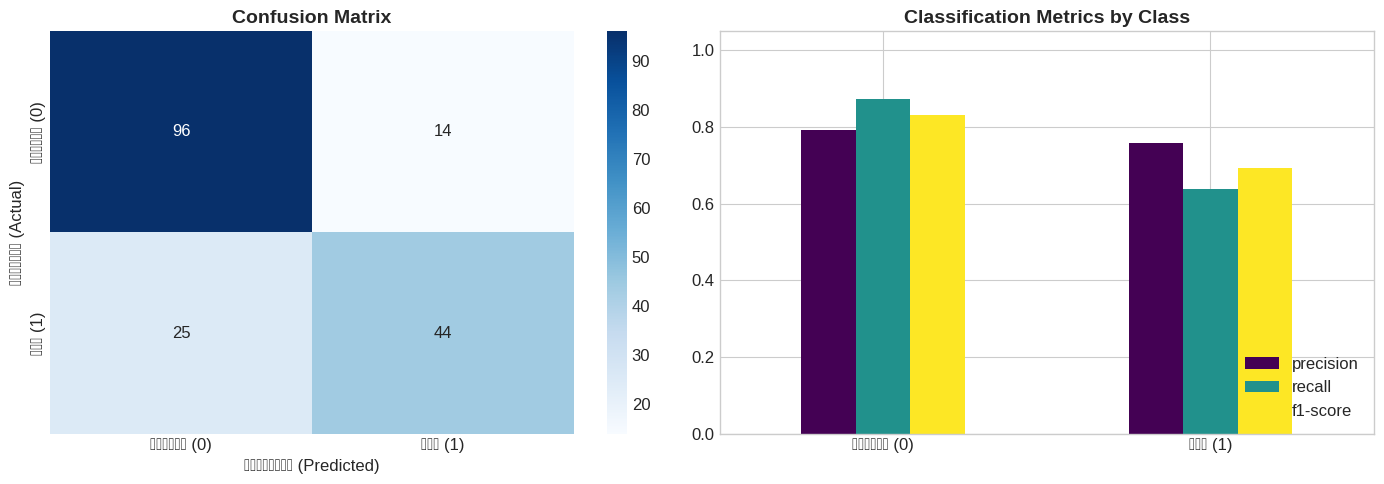


📋 Classification Report:
              precision    recall  f1-score   support

      ไม่รอด       0.79      0.87      0.83       110
         รอด       0.76      0.64      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



In [ ]:
# ใช้โมเดลที่ดีที่สุดจาก section ก่อน
best_model = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf=3, random_state=42)
best_model.fit(X_train_feat, y_train_full)
y_val_pred = best_model.predict(X_validation_feat)

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_validation, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['ไม่รอด (0)', 'รอด (1)'],
            yticklabels=['ไม่รอด (0)', 'รอด (1)'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('ค่าจริง (Actual)')
axes[0].set_xlabel('ค่าทำนาย (Predicted)')

# Classification Report as bar chart
report = classification_report(y_validation, y_val_pred, output_dict=True)
metrics_df = pd.DataFrame(report).T.iloc[:2][['precision', 'recall', 'f1-score']]
metrics_df.index = ['ไม่รอด (0)', 'รอด (1)']
metrics_df.plot(kind='bar', ax=axes[1], rot=0, colormap='viridis')
axes[1].set_title('Classification Metrics by Class', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_validation, y_val_pred, target_names=['ไม่รอด', 'รอด']))

### 🎚️ Threshold Tuning — ปรับ threshold เพื่อเลือก Precision หรือ Recall

> **Before**: ML Model → Yes/No
> **Actually**: ML Model → **Confidence Score** (เช่น Yes: 0.84)

```python
if confidence > threshold:
    label = True
else:
    label = False
```

> **อยากได้ถูกต้อง → เพิ่ม threshold** (Precision สูงขึ้น)
>
> **อยากได้ครบถ้วน → ลด threshold** (Recall สูงขึ้น)

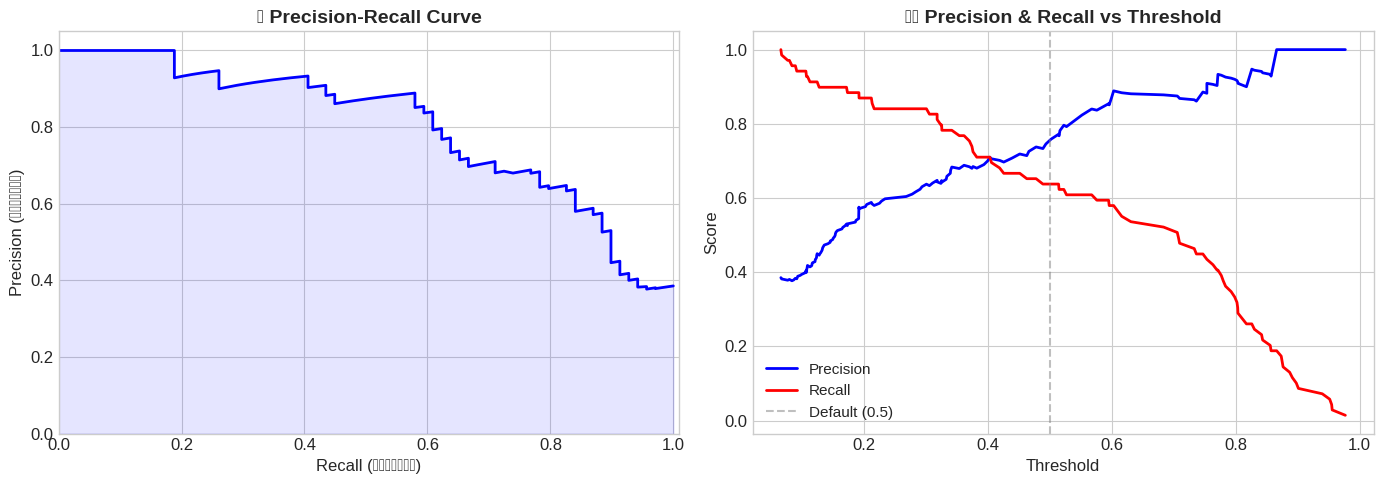


📊 ผลลัพธ์ที่ Threshold ต่างๆ:
 Threshold  Precision     Recall
--------------------------------
       0.3      0.637      0.841
       0.4      0.710      0.710
       0.5      0.759      0.638
       0.6      0.889      0.580
       0.7      0.875      0.507


In [ ]:
# Precision-Recall Curve
y_val_proba = best_model.predict_proba(X_validation_feat)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_validation, y_val_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall Curve
axes[0].plot(recalls, precisions, 'b-', linewidth=2)
axes[0].fill_between(recalls, precisions, alpha=0.1, color='blue')
axes[0].set_xlabel('Recall (ครบถ้วน)', fontsize=12)
axes[0].set_ylabel('Precision (ถูกต้อง)', fontsize=12)
axes[0].set_title('📊 Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[0].set_xlim([0, 1.01])
axes[0].set_ylim([0, 1.05])

# Precision & Recall vs Threshold
axes[1].plot(thresholds, precisions[:-1], 'b-', label='Precision', linewidth=2)
axes[1].plot(thresholds, recalls[:-1], 'r-', label='Recall', linewidth=2)
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('🎚️ Precision & Recall vs Threshold', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# แสดงผลที่ thresholds ต่างๆ
print("\n📊 ผลลัพธ์ที่ Threshold ต่างๆ:")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10}")
print("-" * 32)
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_val_proba >= t).astype(int)
    if y_pred_t.sum() > 0:
        p = (y_validation[y_pred_t == 1] == 1).sum() / y_pred_t.sum()
        r = (y_validation[y_pred_t == 1] == 1).sum() / (y_validation == 1).sum()
        print(f"{t:>10.1f} {p:>10.3f} {r:>10.3f}")

---
# 📈 Section 7: Regression — ทำนายค่าตัวเลข

> **Classification**: Output เป็น Category (เช่น ฝนตกมั้ย? ตก/ไม่ตก)
>
> **Regression**: Output เป็น Number (เช่น ฝนตกกี่ มม.?)

เราจะใช้ **California Housing Dataset** เพื่อทำนายราคาบ้าน

In [ ]:
# โหลด California Housing dataset
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df_housing = housing.frame
print(f"📊 Dataset shape: {df_housing.shape}")
print(f"\n🏠 Features:")
for col in housing.feature_names:
    print(f"   - {col}")
print(f"\n🎯 Target: MedHouseVal (median house value in $100,000s)")
df_housing.head()

📊 Dataset shape: (20640, 9)

🏠 Features:
   - MedInc
   - HouseAge
   - AveRooms
   - AveBedrms
   - Population
   - AveOccup
   - Latitude
   - Longitude

🎯 Target: MedHouseVal (median house value in $100,000s)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# เตรียมข้อมูล Regression
X_reg = df_housing.drop(columns=['MedHouseVal'])
y_reg = df_housing['MedHouseVal']

# Train/Val split
X_reg_train, X_reg_val, y_reg_train, y_reg_val = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scale features
scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_val_scaled = scaler_reg.transform(X_reg_val)

# เทรน RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
rf_reg.fit(X_reg_train_scaled, y_reg_train)
y_reg_pred = rf_reg.predict(X_reg_val_scaled)

# Regression Metrics
mae = mean_absolute_error(y_reg_val, y_reg_pred)
mse = mean_squared_error(y_reg_val, y_reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_val, y_reg_pred)

print("📏 Regression Evaluation Metrics:")
print(f"   MAE  (Mean Absolute Error):  {mae:.4f}  (~${mae*100000:,.0f})")
print(f"   MSE  (Mean Squared Error):   {mse:.4f}")
print(f"   RMSE (Root MSE):             {rmse:.4f}  (~${rmse*100000:,.0f})")
print(f"   R²   (R-squared):            {r2:.4f}  ({r2*100:.1f}% variance explained)")

📏 Regression Evaluation Metrics:
   MAE  (Mean Absolute Error):  0.3332  (~$33,316)
   MSE  (Mean Squared Error):   0.2615
   RMSE (Root MSE):             0.5113  (~$51,132)
   R²   (R-squared):            0.8005  (80.0% variance explained)


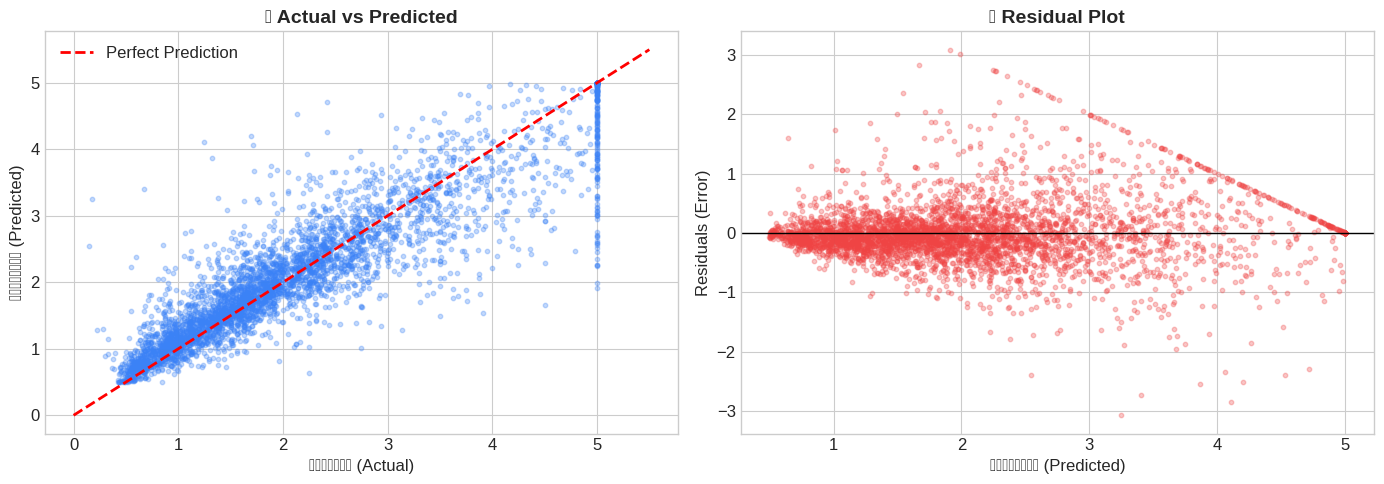

In [ ]:
# Actual vs Predicted scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_reg_val, y_reg_pred, alpha=0.3, s=10, color='#3b82f6')
axes[0].plot([0, 5.5], [0, 5.5], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('ค่าจริง (Actual)', fontsize=12)
axes[0].set_ylabel('ค่าทำนาย (Predicted)', fontsize=12)
axes[0].set_title('🎯 Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0].legend()

# Residual plot
residuals = y_reg_val - y_reg_pred
axes[1].scatter(y_reg_pred, residuals, alpha=0.3, s=10, color='#ef4444')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('ค่าทำนาย (Predicted)', fontsize=12)
axes[1].set_ylabel('Residuals (Error)', fontsize=12)
axes[1].set_title('📊 Residual Plot', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---
# 🧬 Section 8: Ensemble Methods

> **"เอาหลายโมเดลมาช่วยกัน Predict จะได้เก่งขึ้น"**

### แก้ปัญหาได้:
- ✅ Overfitting
- ✅ Underfitting

### ประเภท Ensemble:
- **Bagging**: เทรนหลายโมเดลแบบ parallel (เช่น Random Forest)
- **Boosting**: เทรนโมเดลต่อกัน แต่ละตัวแก้ข้อผิดของตัวก่อนหน้า (เช่น XGBoost)
- **Stacking**: เอา output ของหลายโมเดลมาเป็น input ของอีกโมเดลนึง

In [ ]:
# Ensemble: VotingClassifier
from sklearn.tree import DecisionTreeClassifier

# สร้าง individual models
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_rf = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42)
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# VotingClassifier (soft voting = ใช้ probability เฉลี่ย)
ensemble = VotingClassifier(
    estimators=[('lr', model_lr), ('rf', model_rf), ('dt', model_dt)],
    voting='soft'
)

best_model.fit(X_train_feat, y_train_full)
y_val_pred = best_model.predict(X_validation_feat)

# Scale data สำหรับ Logistic Regression
scaler_cls = StandardScaler()
X_train_scaled = scaler_cls.fit_transform(X_train_feat)
X_val_scaled = scaler_cls.transform(X_validation_feat)

# เทรนและเปรียบเทียบ
results = {}
for name, model in [('Logistic Regression', model_lr), ('Random Forest', model_rf),
                      ('Decision Tree', model_dt), ('🏆 Ensemble (Voting)', ensemble)]:
    model.fit(X_train_scaled, y_train_full)
    score = model.score(X_val_scaled, y_validation)
    results[name] = score

print("📊 เปรียบเทียบ Single Model vs Ensemble:")
print(f"{'Model':<30} {'Val Accuracy':>12}")
print("-" * 44)
for name, score in results.items():
    bar = '█' * int(score * 40)
    print(f"{name:<30} {score:>12.4f}  {bar}")

📊 เปรียบเทียบ Single Model vs Ensemble:
Model                          Val Accuracy
--------------------------------------------
Logistic Regression                  0.8156  ████████████████████████████████
Random Forest                        0.7877  ███████████████████████████████
Decision Tree                        0.7542  ██████████████████████████████
🏆 Ensemble (Voting)                  0.7877  ███████████████████████████████


---
# ⚡ Section 9: AutoML ด้วย AutoGluon

### สิ่งที่ AutoML ทำได้ดี ✅
- ลอง Model ทุกรูปแบบ + Ensemble
- ลอง Hyperparameter หลายแบบ
- ลอง Feature Selection แต่ละวิธี

### สิ่งที่ AutoML ทำไม่ได้ หรือได้ไม่ดี ❌
1. Feature Engineering แต่ละแบบ
2. แก้ Imbalanced Dataset (ที่ซับซ้อน)
3. ระวัง Data Leakage
4. เลือกวิธีวัดผลที่ตรงกับ Hackathon ต้องการ

> **"AutoML จะไม่ลองทุกอย่าง แต่จะมี Algorithm อยู่ว่าต้องลองอะไรบ้างจาก result ของวิธีที่ลองไปแล้ว"

### 9.1 AutoGluon — Classification (Titanic)

In [ ]:
# PyCaret Classification
from autogluon.tabular import TabularPredictor
predictor = TabularPredictor(label="Survived").fit(pd.concat([X_train_feat, y_train_full], axis = 1), presets="medium_quality")

No path specified. Models will be saved in: "AutogluonModels/ag-20260311_165812"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.73 GB / 12.67 GB (84.7%)
Disk Space Avail:   74.74 GB / 107.72 GB (69.4%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ...
AutoGluon will save models to "/content/AutogluonModels/ag-20260311_165812"
Train Data Rows:    712
Train Data Columns: 13
Label Column:       Survived
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [np.int64(1), np.int64(0)]
	If 'binary' is not the correct problem_type,

### 9.2 AutoGluon — Regression (California Housing)

In [ ]:
# AutoGLuon Regression
from autogluon.tabular import TabularPredictor

# ใช้ sample ของ California Housing (AutoGLuon ใน Colab อาจช้ากับ data เยอะ)
df_pycaret_reg = df_housing.sample(n=5000, random_state=42).reset_index(drop=True)

from autogluon.tabular import TabularPredictor
predictor_regression = TabularPredictor(label="MedHouseVal").fit(df_pycaret_reg, presets="medium_quality")

No path specified. Models will be saved in: "AutogluonModels/ag-20260311_165844"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.53 GB / 12.67 GB (83.1%)
Disk Space Avail:   74.68 GB / 107.72 GB (69.3%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ...
AutoGluon will save models to "/content/AutogluonModels/ag-20260311_165844"
Train Data Rows:    5000
Train Data Columns: 8
Label Column:       MedHouseVal
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (5.00001, 0.14999, 2.

[1000]	valid_set's rmse: 0.488444
[2000]	valid_set's rmse: 0.47811
[3000]	valid_set's rmse: 0.473754
[4000]	valid_set's rmse: 0.472743


	-0.4723	 = Validation score   (-root_mean_squared_error)
	4.33s	 = Training   runtime
	0.3s	 = Validation runtime
Fitting model: LightGBM ...
	Fitting with cpus=1, gpus=0, mem=0.0/10.5 GB


[1000]	valid_set's rmse: 0.453816


	-0.4531	 = Validation score   (-root_mean_squared_error)
	1.9s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: RandomForestMSE ...
	Fitting with cpus=2, gpus=0, mem=0.0/10.5 GB
	-0.5545	 = Validation score   (-root_mean_squared_error)
	11.57s	 = Training   runtime
	0.19s	 = Validation runtime
Fitting model: CatBoost ...
	Fitting with cpus=1, gpus=0
	-0.4379	 = Validation score   (-root_mean_squared_error)
	42.59s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: ExtraTreesMSE ...
	Fitting with cpus=2, gpus=0, mem=0.0/10.5 GB
	-0.5532	 = Validation score   (-root_mean_squared_error)
	3.14s	 = Training   runtime
	0.13s	 = Validation runtime
Fitting model: NeuralNetFastAI ...
	Fitting with cpus=1, gpus=0, mem=0.0/10.5 GB
	-0.5801	 = Validation score   (-root_mean_squared_error)
	6.89s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: XGBoost ...
	Fitting with cpus=1, gpus=0
	-0.4661	 = Validation score   (-root_mean_squared_error)
	4.77s	

[1000]	valid_set's rmse: 0.479282
[2000]	valid_set's rmse: 0.478897
[3000]	valid_set's rmse: 0.478893


	-0.4789	 = Validation score   (-root_mean_squared_error)
	11.89s	 = Training   runtime
	0.45s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ...
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.0/10.5 GB
	Ensemble Weights: {'CatBoost': 0.696, 'LightGBM': 0.261, 'XGBoost': 0.043}
	-0.4349	 = Validation score   (-root_mean_squared_error)
	0.03s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 185.85s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 5040.3 rows/s (500 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/content/AutogluonModels/ag-20260311_165844")


---
# 📝 Section 10: Text → Numerical ด้วย Sentence Transformers

> **"Machine Learning เข้าใจแค่ตัวเลขเท่านั้น"**
>
> ตัวหนังสือที่ไม่ใช่ Category → ต้องแปลงเป็น vector ของตัวเลข (Embedding)

### Sentence Transformers:
- แปลงประโยค → vector ขนาดคงที่ (เช่น 384 มิติ)
- ประโยคที่ความหมายคล้ายกัน → vector ใกล้กัน

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# โหลด pretrained model
st_model = SentenceTransformer("all-MiniLM-L6-v2")

# ตัวอย่างจาก Slide
sentences_en = [
    "The weather is lovely today.",
    "It's so sunny outside!",
    "He drove to the stadium.",
]

embeddings_en = st_model.encode(sentences_en)
print(f"📐 Embedding shape: {embeddings_en.shape}")
print(f"   → {len(sentences_en)} ประโยค × {embeddings_en.shape[1]} มิติ")

# Cosine Similarity
sim_matrix = cosine_similarity(embeddings_en)
print("\n📊 Cosine Similarity Matrix:")
sim_df = pd.DataFrame(sim_matrix, index=[f"Sent {i+1}" for i in range(3)],
                       columns=[f"Sent {i+1}" for i in range(3)])
print(sim_df.round(3).to_string())
print("\n💡 Sent 1 & 2 (ทั้งคู่พูดเรื่องอากาศ) มี similarity สูงกว่า Sent 3 (เรื่องขับรถ)")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

📐 Embedding shape: (3, 384)
   → 3 ประโยค × 384 มิติ

📊 Cosine Similarity Matrix:
        Sent 1  Sent 2  Sent 3
Sent 1   1.000   0.666   0.105
Sent 2   0.666   1.000   0.141
Sent 3   0.105   0.141   1.000

💡 Sent 1 & 2 (ทั้งคู่พูดเรื่องอากาศ) มี similarity สูงกว่า Sent 3 (เรื่องขับรถ)


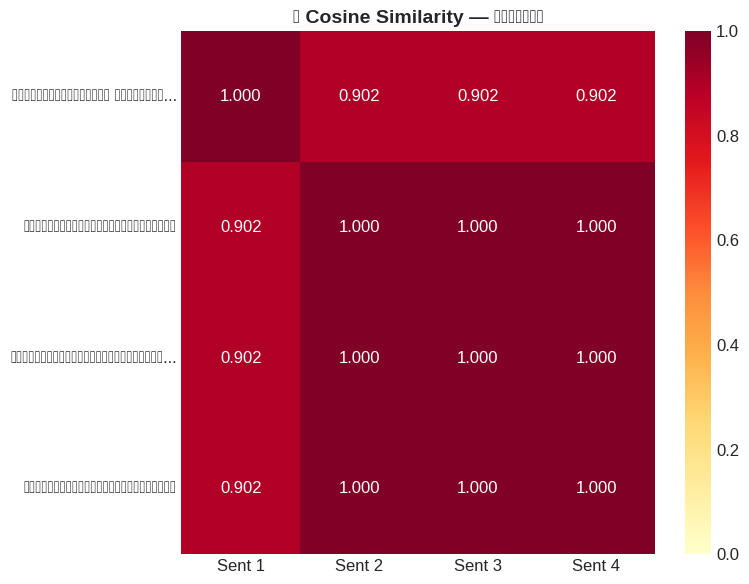


💡 หมายเหตุ: model all-MiniLM-L6-v2 เทรนจากภาษาอังกฤษเป็นหลัก
   สำหรับภาษาไทยโดยเฉพาะ ลองใช้ multilingual models เช่น:
   - paraphrase-multilingual-MiniLM-L12-v2
   - intfloat/multilingual-e5-small


In [ ]:
# ตัวอย่างภาษาไทย
sentences_th = [
    "วันนี้อากาศดีมาก ท้องฟ้าสดใส",
    "อากาศแจ่มใสน่าออกไปเที่ยว",
    "ผมไปซื้อข้าวที่ตลาดเมื่อวาน",
    "สุนัขวิ่งเล่นในสวนสาธารณะ",
]

embeddings_th = st_model.encode(sentences_th)

sim_matrix_th = cosine_similarity(embeddings_th)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(sim_matrix_th, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=[f"Sent {i+1}" for i in range(len(sentences_th))],
            yticklabels=[s[:25]+'...' if len(s)>25 else s for s in sentences_th],
            ax=ax, vmin=0, vmax=1)
ax.set_title('📊 Cosine Similarity — ภาษาไทย', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 หมายเหตุ: model all-MiniLM-L6-v2 เทรนจากภาษาอังกฤษเป็นหลัก")
print("   สำหรับภาษาไทยโดยเฉพาะ ลองใช้ multilingual models เช่น:")
print("   - paraphrase-multilingual-MiniLM-L12-v2")
print("   - intfloat/multilingual-e5-small")

# Section 11: ส่ง Result ลงใน Kaggle

In [ ]:
predictions_auto_gluon = predictor.predict(df_test_feature)
predictions_auto_gluon

,Survived
0,0
1,0
2,0
3,0
4,1
...,...
413,0
414,1
415,0
416,0


In [ ]:
predictions_random_forest = rf_model.predict(df_test_feature)
predictions_random_forest

array([0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
submission_df = pd.read_csv('gender_submission.csv')
submission_df

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [ ]:
predictions_auto_gluon = pd.concat([predictions_auto_gluon, df_test[['PassengerId']]], axis = 1)
predictions_auto_gluon.to_csv('predictions_auto_gluon.csv', index = False)
predictions_auto_gluon

,Survived,PassengerId
0,0,892
1,0,893
2,0,894
3,0,895
4,1,896
...,...,...
413,0,1305
414,1,1306
415,0,1307
416,0,1308


## Submit AutoGluon Result at Kaggle
- https://www.kaggle.com/competitions/titanic/submissions
- `predictions_auto_gluon.csv`



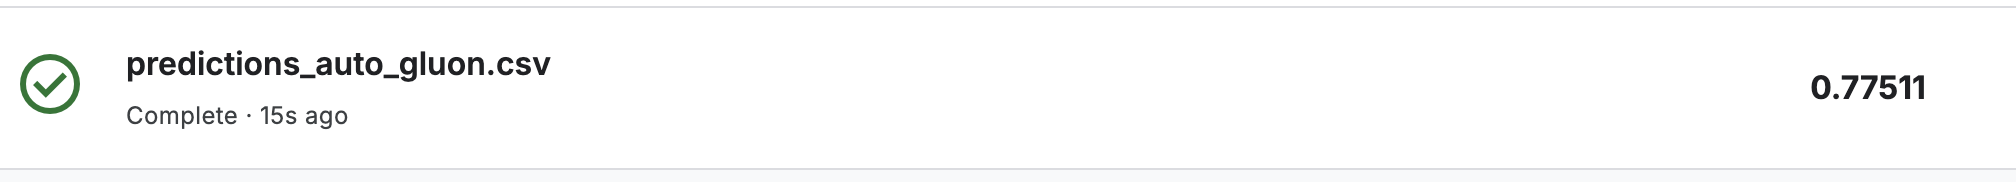

In [ ]:
predictions_random_forest_df = df_test[['PassengerId']].copy()

predictions_random_forest_df['Survived'] = predictions_random_forest
predictions_random_forest_df.to_csv('predictions_random_forest.csv', index = False)
predictions_random_forest_df

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


## Submit RandomForest Result at Kaggle
- https://www.kaggle.com/competitions/titanic/submissions
- `predictions_random_forest.csv`


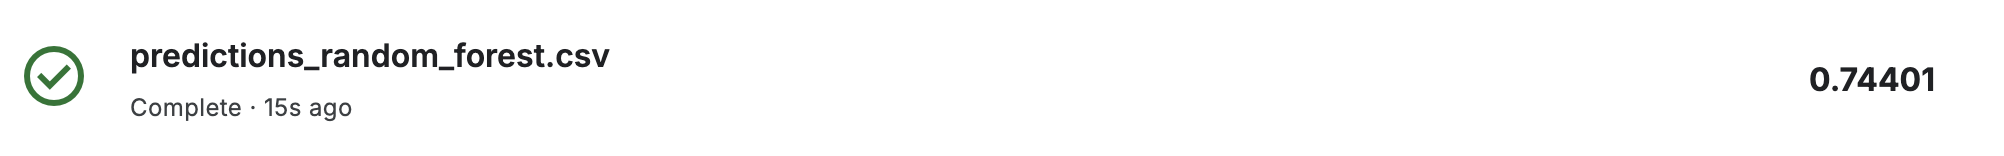

---
# 🎯 Section 12: สรุป & Hackathon Strategy

## ML Pipeline ที่เราเรียนรู้ในวันนี้

```
Raw Data → Preprocessing → Feature Engineering → Model Training → Evaluation → Prediction
              ↓                    ↓                    ↓              ↓
        Missing Values        FamilySize         RandomForest     Precision
        Outliers (IQR)        IsAlone           VotingClassifier  Recall
        Encoding              Title              PyCaret AutoML   F1 / MAE
        Scaling                                                    RMSE / R²
```

## 🏆 Hackathon Checklist (เรียงตามลำดับ)

1. **ลอง Model ทุกรูปแบบ** → ใช้ PyCaret เปรียบเทียบ
2. **ลอง Hyperparameter หลายแบบ** → GridSearch / RandomSearch
3. **ลอง Feature Selection แต่ละวิธี** → Correlation, Mutual Information
4. **ลอง Feature Engineering แต่ละแบบ** → ⚠️ AutoML ทำไม่ได้ ต้องทำเอง!
5. **เก็บข้อมูลเพิ่ม** (ชีวิตจริง) — เพิ่ม rows + เพิ่ม features

> **"ลองจนมั่นใจแล้วค่อย Submit"** 🚀

### 📚 Resources เพิ่มเติม
- [scikit-learn Cheat Sheet](https://scikit-learn.org/1.4/tutorial/machine_learning_map/index.html) — เลือกโมเดลที่เหมาะสม
- [PyCaret Documentation](https://pycaret.gitbook.io/) — AutoML
- [SBERT.net](https://sbert.net) — Sentence Transformers
- [Kaggle](https://www.kaggle.com/) — Datasets & Competitions